# Model Training — Improved Pipeline

Consolidated notebook incorporating all improvements:
1. **Objective** → `f1_macro` with soft recall floor (≥ 0.85)
2. **Dynamic `scale_pos_weight`** tuned by Optuna in [1.0, 5.0]
3. **SMOTETomek** replaces plain SMOTE
4. **SelectFromModel** (RF-based) feature selection step
5. **LightGBM** added as a fourth model candidate
6. **Risk tiering** for enrolled students
7. **SHAP explainability** (global + local)

Steps:
1. Imports & Config
2. Feature Preparation
3. Label Propagation
4. HPO Pipeline (Optuna)
5. Threshold Tuning
6. Export Model
7. Risk Tiering
8. SHAP Explainability

## Imports & Config

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import (
    make_scorer, recall_score, precision_score, f1_score, accuracy_score,
)
from sklearn.base import clone

from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTETomek

# ── Global config ──────────────────────────────────────────────────────────────
RANDOM_STATE             = 42
ENROLLED_PSEUDO_THRESHOLD = 0.6

XGB_GPU_PARAMS = {
    'tree_method': 'hist',
    'device': 'cuda',
    'random_state': RANDOM_STATE
}

# LightGBM: Requires LightGBM to be compiled with GPU support
LGBM_GPU_PARAMS = {
    'device_type': 'gpu',
    'random_state': RANDOM_STATE
}

print(f'RANDOM_STATE              = {RANDOM_STATE}')
print(f'ENROLLED_PSEUDO_THRESHOLD = {ENROLLED_PSEUDO_THRESHOLD}')
print('CUDA configurations for XGBoost and LightGBM are set.')

RANDOM_STATE              = 42
ENROLLED_PSEUDO_THRESHOLD = 0.6
CUDA configurations for XGBoost and LightGBM are set.


## Feature Preparation

In [3]:
df = pd.read_csv('../data/processed/processed_dataset.csv')
print(f'Loaded dataset: {df.shape}')

UNSCALED_TO_DROP = [
    'Age at enrollment',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Unemployment rate',
    'Inflation rate',
    'GDP',
    'semester_performance_delta'
]
TARGET_COLS = ['Target', 'Target_Encoded', 'Target_Binary']

X = df.drop(columns=TARGET_COLS + UNSCALED_TO_DROP)
print(f'Feature matrix shape: {X.shape}')
print(f'Features ({len(X.columns)}):', X.columns.tolist())

labeled_mask  = df['Target_Binary'].notna()
enrolled_mask = df['Target'] == 'Enrolled'

X_labeled  = X[labeled_mask].reset_index(drop=True)
y_labeled  = df.loc[labeled_mask, 'Target_Binary'].astype(int).reset_index(drop=True)
X_enrolled = X[enrolled_mask].reset_index(drop=True)
df_enrolled = df[enrolled_mask].reset_index(drop=True)

print(f'\nLabeled set shape  : {X_labeled.shape}')
print('Class distribution (labeled):')
print(y_labeled.value_counts().rename({0: 'Graduate (0)', 1: 'Dropout (1)'}).to_string())
print(f'\nEnrolled set shape : {X_enrolled.shape}')

Loaded dataset: (4424, 49)
Feature matrix shape: (4424, 39)
Features (39): ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (without evaluations)', 'zero_approved_units_flag', 'financial_stress_flag', 'engagement_ratio_1st_sem', 'engagement_ratio_2nd_sem', 'Age at enrollment_scaled', 'Cu

## Label Propagation

In [4]:
# Fit KNN on hard-labeled set, propagate probabilities to Enrolled students,
# and promote high-confidence predictions as pseudo-labeled training samples.

knn = KNeighborsClassifier(n_neighbors=15, weights='distance')
knn.fit(X_labeled, y_labeled)

proba_enrolled = knn.predict_proba(X_enrolled)

if np.isnan(proba_enrolled).any():
    raise ValueError('Label propagation produced NaN probabilities.')

p_graduate = proba_enrolled[:, 0]
p_dropout  = proba_enrolled[:, 1]

pseudo_indices_dropout   = []
pseudo_indices_graduate  = []
pseudo_indices_ambiguous = []

for i in range(len(X_enrolled)):
    if p_dropout[i] > ENROLLED_PSEUDO_THRESHOLD:
        pseudo_indices_dropout.append(i)
    elif p_graduate[i] > ENROLLED_PSEUDO_THRESHOLD:
        pseudo_indices_graduate.append(i)
    else:
        pseudo_indices_ambiguous.append(i)

n_pseudo_dropout  = len(pseudo_indices_dropout)
n_pseudo_graduate = len(pseudo_indices_graduate)
n_ambiguous       = len(pseudo_indices_ambiguous)

print(f'Pseudo-labeled Dropout  : {n_pseudo_dropout}')
print(f'Pseudo-labeled Graduate : {n_pseudo_graduate}')
print(f'Ambiguous (excluded)    : {n_ambiguous}')
print(f'Total Enrolled          : {len(X_enrolled)}')

all_pseudo_indices = pseudo_indices_dropout + pseudo_indices_graduate

if len(all_pseudo_indices) == 0:
    import warnings as _w
    _w.warn('All Enrolled students are ambiguous. Proceeding with labeled set only.', UserWarning)
    X_train_aug = X_labeled
    y_train_aug = y_labeled
    w_train_aug = np.ones(len(X_labeled))
else:
    X_pseudo_dropout  = X_enrolled.iloc[pseudo_indices_dropout]
    y_pseudo_dropout  = pd.Series([1] * n_pseudo_dropout, dtype=int)
    w_pseudo_dropout  = p_dropout[pseudo_indices_dropout]

    X_pseudo_graduate = X_enrolled.iloc[pseudo_indices_graduate]
    y_pseudo_graduate = pd.Series([0] * n_pseudo_graduate, dtype=int)
    w_pseudo_graduate = p_graduate[pseudo_indices_graduate]

    X_pseudo = pd.concat([X_pseudo_dropout, X_pseudo_graduate], ignore_index=True)
    y_pseudo = pd.concat([y_pseudo_dropout, y_pseudo_graduate], ignore_index=True)
    w_pseudo = np.concatenate([w_pseudo_dropout, w_pseudo_graduate])

    X_train_aug = pd.concat([X_labeled, X_pseudo], ignore_index=True)
    y_train_aug = pd.concat([y_labeled, y_pseudo], ignore_index=True)
    w_train_aug = np.concatenate([np.ones(len(X_labeled)), w_pseudo])

print(f'\nAugmented training set shape : {X_train_aug.shape}')
print('Class distribution (augmented):')
print(y_train_aug.value_counts().rename({0: 'Graduate (0)', 1: 'Dropout (1)'}).to_string())

Pseudo-labeled Dropout  : 110
Pseudo-labeled Graduate : 520
Ambiguous (excluded)    : 164
Total Enrolled          : 794

Augmented training set shape : (4260, 39)
Class distribution (augmented):
Graduate (0)    2729
Dropout (1)     1531


## HPO Pipeline (Optuna)


── Logistic Regression ──────────────────────────────────────────────────


  0%|          | 0/100 [00:00<?, ?it/s]

  Best params  : {'selector_threshold': '0.5*mean', 'C': 0.1061704886840409, 'solver': 'lbfgs', 'class_weight': None}
  Best f1_macro (penalised): 0.8624
  Recall       : 0.8432 ± 0.0217
  Precision    : 0.8398 ± 0.0110
  F1-macro     : 0.8759 ± 0.0056
  Accuracy     : 0.8857 ± 0.0047

── Random Forest ──────────────────────────────────────────────────


  0%|          | 0/100 [00:00<?, ?it/s]

  Best params  : {'selector_threshold': '0.5*mean', 'n_estimators': 115, 'max_depth': 20, 'min_samples_split': 10, 'class_weight': None}
  Best f1_macro (penalised): 0.8231
  Recall       : 0.8204 ± 0.0154
  Precision    : 0.8747 ± 0.0089
  F1-macro     : 0.8823 ± 0.0073
  Accuracy     : 0.8932 ± 0.0063

── XGBoost ──────────────────────────────────────────────────


  0%|          | 0/100 [00:00<?, ?it/s]

  Best params  : {'selector_threshold': '0.5*mean', 'n_estimators': 417, 'learning_rate': 0.024330228678966854, 'max_depth': 6, 'subsample': 0.7, 'colsample_bytree': 0.8, 'scale_pos_weight': 2.8352708373852917}
  Best f1_macro (penalised): 0.8777
  Recall       : 0.8498 ± 0.0202
  Precision    : 0.8395 ± 0.0159
  F1-macro     : 0.8782 ± 0.0109
  Accuracy     : 0.8876 ± 0.0099

── LightGBM ──────────────────────────────────────────────────


  0%|          | 0/100 [00:00<?, ?it/s]

  Best params  : {'selector_threshold': '0.5*mean', 'n_estimators': 297, 'learning_rate': 0.025462895241171634, 'max_depth': 5, 'num_leaves': 47, 'subsample': 0.7, 'colsample_bytree': 0.6, 'scale_pos_weight': 1.9959731330996924}
  Best f1_macro (penalised): 0.8758
  Recall       : 0.8498 ± 0.0227
  Precision    : 0.8354 ± 0.0156
  F1-macro     : 0.8763 ± 0.0099
  Accuracy     : 0.8857 ± 0.0089

── HPO complete ──────────────────────────────────────────────────────

Best model: XGBoost  (f1_macro=0.8782, recall=0.8498)


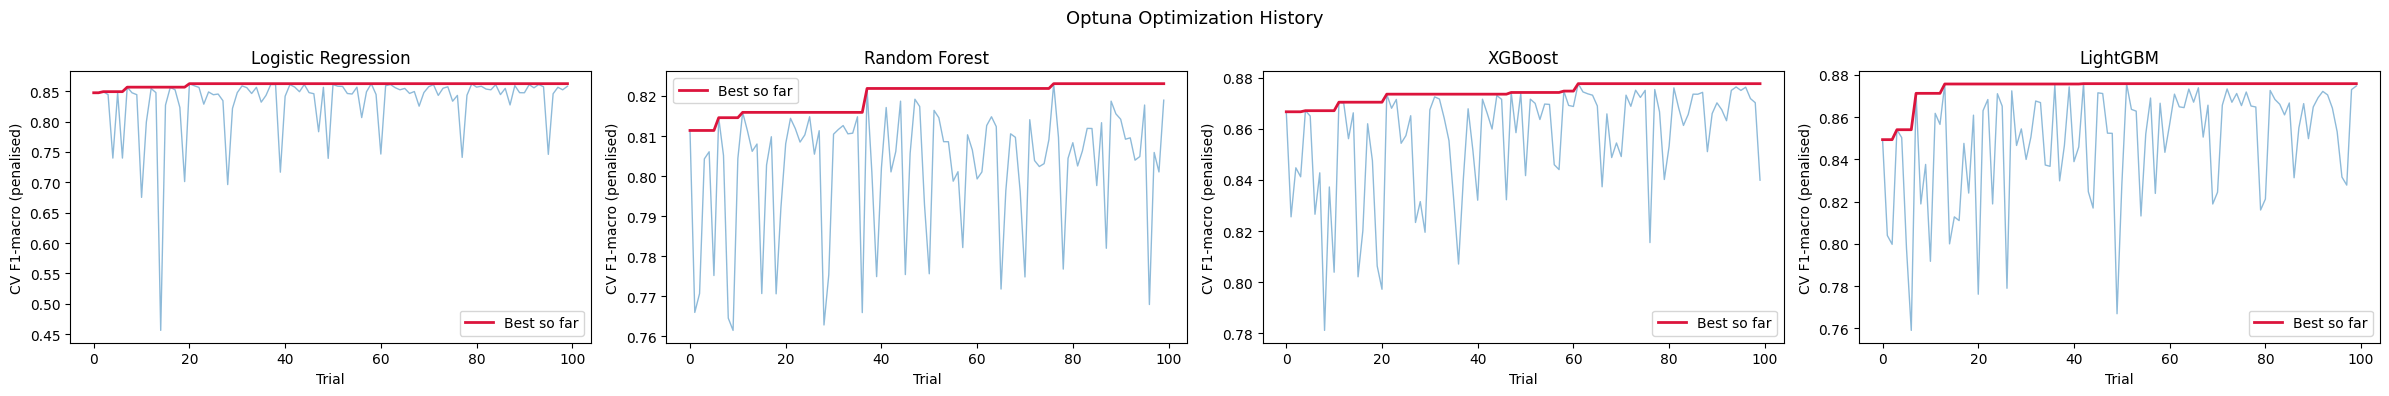


HPO Results Summary:
                              Recall        Precision         F1-macro         Accuracy
Model                                                                                  
Logistic Regression  0.8432 ± 0.0217  0.8398 ± 0.0110  0.8759 ± 0.0056  0.8857 ± 0.0047
Random Forest        0.8204 ± 0.0154  0.8747 ± 0.0089  0.8823 ± 0.0073  0.8932 ± 0.0063
XGBoost              0.8498 ± 0.0202  0.8395 ± 0.0159  0.8782 ± 0.0109  0.8876 ± 0.0099
LightGBM             0.8498 ± 0.0227  0.8354 ± 0.0156  0.8763 ± 0.0099  0.8857 ± 0.0089


In [5]:
# Improvements vs. original:
#   1. Objective = f1_macro with soft recall floor (>= RECALL_FLOOR)
#   2. scale_pos_weight tuned as continuous float [1.0, 5.0]
#   3. SMOTETomek replaces plain SMOTE
#   4. SelectFromModel (RF-based) feature selection step
#   5. LightGBM added as a fourth model candidate

N_TRIALS      = 100
N_CV_FOLDS    = 5
RECALL_FLOOR  = 0.85   # minimum acceptable Dropout recall
RECALL_PENALTY = 2.0   # penalty multiplier when recall < RECALL_FLOOR

cv = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'recall':    make_scorer(recall_score,    pos_label=1),
    'precision': make_scorer(precision_score, pos_label=1, zero_division=0),
    'f1_macro':  make_scorer(f1_score,        average='macro'),
    'accuracy':  make_scorer(accuracy_score),
}

# ── 4a. Per-model objective factories ─────────────────────────────────────────

def make_objective(model_name, X, y):
    """Return an Optuna objective function for the given model family."""

    def objective(trial):
        # Feature selection step (shared by all models)
        selector_threshold = trial.suggest_categorical(
            'selector_threshold', ['mean', '0.5*mean', '1.5*mean']
        )
        selector = SelectFromModel(
            RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
            threshold=selector_threshold,
        )

        if model_name == 'Logistic Regression':
            clf = LogisticRegression(
                C            = trial.suggest_float('C', 1e-3, 100, log=True),
                solver       = trial.suggest_categorical('solver', ['lbfgs', 'liblinear']),
                class_weight = trial.suggest_categorical('class_weight', ['balanced', None]),
                max_iter     = 1000,
                random_state = RANDOM_STATE,
            )

        elif model_name == 'Random Forest':
            clf = RandomForestClassifier(
                n_estimators      = trial.suggest_int('n_estimators', 100, 500),
                max_depth         = trial.suggest_categorical('max_depth', [None, 5, 10, 20]),
                min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
                class_weight      = trial.suggest_categorical('class_weight', ['balanced', None]),
                random_state      = RANDOM_STATE,
                n_jobs            = -1,
            )

        elif model_name == 'XGBoost':
            clf = XGBClassifier(
                n_estimators     = trial.suggest_int('n_estimators', 100, 500),
                learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                max_depth        = trial.suggest_int('max_depth', 3, 10),
                subsample        = trial.suggest_categorical('subsample', [0.6, 0.7, 0.8, 0.9, 1.0]),
                colsample_bytree = trial.suggest_categorical('colsample_bytree', [0.6, 0.7, 0.8, 0.9, 1.0]),
                scale_pos_weight = trial.suggest_float('scale_pos_weight', 1.0, 5.0),
                eval_metric      = 'logloss',
                random_state     = RANDOM_STATE,
            )

        else:  # LightGBM
            clf = LGBMClassifier(
                n_estimators     = trial.suggest_int('n_estimators', 100, 500),
                learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                max_depth        = trial.suggest_int('max_depth', 3, 10),
                num_leaves       = trial.suggest_int('num_leaves', 20, 150),
                subsample        = trial.suggest_categorical('subsample', [0.6, 0.7, 0.8, 0.9, 1.0]),
                colsample_bytree = trial.suggest_categorical('colsample_bytree', [0.6, 0.7, 0.8, 0.9, 1.0]),
                scale_pos_weight = trial.suggest_float('scale_pos_weight', 1.0, 5.0),
                random_state     = RANDOM_STATE,
                n_jobs           = -1,
                verbose          = -1,
            )

        # Pipeline: SMOTETomek -> SelectFromModel -> Classifier
        pipeline = Pipeline([
            ('smotetomek', SMOTETomek(random_state=RANDOM_STATE)),
            ('selector',   selector),
            ('clf',        clf),
        ])

        # Objective: f1_macro with soft recall floor
        cv_scores = cross_validate(
            pipeline, X, y,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            return_train_score=False,
        )
        mean_f1_macro = cv_scores['test_f1_macro'].mean()
        mean_recall   = cv_scores['test_recall'].mean()

        if mean_recall < RECALL_FLOOR:
            shortfall = RECALL_FLOOR - mean_recall
            return mean_f1_macro - RECALL_PENALTY * shortfall

        return mean_f1_macro

    return objective


# ── 4b. Run one Optuna study per model ────────────────────────────────────────
hpo_results  = {}
best_studies = {}

for model_name in ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']:
    print(f'\n── {model_name} ──────────────────────────────────────────────────')

    pruner  = MedianPruner(n_startup_trials=10) if model_name in ('XGBoost', 'LightGBM') \
              else optuna.pruners.NopPruner()
    sampler = TPESampler(seed=RANDOM_STATE)

    study = optuna.create_study(direction='maximize', sampler=sampler, pruner=pruner)
    study.optimize(
        make_objective(model_name, X_train_aug, y_train_aug),
        n_trials=N_TRIALS,
        show_progress_bar=True,
    )

    best_params = study.best_params
    best_trial  = study.best_trial
    print(f'  Best params  : {best_params}')
    print(f'  Best f1_macro (penalised): {best_trial.value:.4f}')

    # Rebuild best pipeline and re-run CV to collect all metrics
    selector_threshold = best_params['selector_threshold']
    selector = SelectFromModel(
        RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
        threshold=selector_threshold,
    )

    if model_name == 'Logistic Regression':
        best_clf = LogisticRegression(
            C=best_params['C'], solver=best_params['solver'],
            class_weight=best_params['class_weight'],
            max_iter=1000, random_state=RANDOM_STATE,
        )
    elif model_name == 'Random Forest':
        best_clf = RandomForestClassifier(
            n_estimators=best_params['n_estimators'],
            max_depth=best_params['max_depth'],
            min_samples_split=best_params['min_samples_split'],
            class_weight=best_params['class_weight'],
            random_state=RANDOM_STATE, n_jobs=-1,
        )
    elif model_name == 'XGBoost':
        best_clf = XGBClassifier(
            n_estimators=best_params['n_estimators'],
            learning_rate=best_params['learning_rate'],
            max_depth=best_params['max_depth'],
            subsample=best_params['subsample'],
            colsample_bytree=best_params['colsample_bytree'],
            scale_pos_weight=best_params['scale_pos_weight'],
            eval_metric='logloss', random_state=RANDOM_STATE,
        )
    else:  # LightGBM
        best_clf = LGBMClassifier(
            n_estimators=best_params['n_estimators'],
            learning_rate=best_params['learning_rate'],
            max_depth=best_params['max_depth'],
            num_leaves=best_params['num_leaves'],
            subsample=best_params['subsample'],
            colsample_bytree=best_params['colsample_bytree'],
            scale_pos_weight=best_params['scale_pos_weight'],
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
        )

    best_pipeline = Pipeline([
        ('smotetomek', SMOTETomek(random_state=RANDOM_STATE)),
        ('selector',   selector),
        ('clf',        best_clf),
    ])

    cv_scores = cross_validate(
        best_pipeline, X_train_aug, y_train_aug,
        cv=cv, scoring=scoring, n_jobs=-1,
    )

    mean_recall    = cv_scores['test_recall'].mean()
    std_recall     = cv_scores['test_recall'].std()
    mean_precision = cv_scores['test_precision'].mean()
    std_precision  = cv_scores['test_precision'].std()
    mean_f1_macro  = cv_scores['test_f1_macro'].mean()
    std_f1_macro   = cv_scores['test_f1_macro'].std()
    mean_accuracy  = cv_scores['test_accuracy'].mean()
    std_accuracy   = cv_scores['test_accuracy'].std()

    best_pipeline.fit(X_train_aug, y_train_aug)

    hpo_results[model_name] = {
        'best_estimator':    best_pipeline,
        'best_f1_macro_cv':  best_trial.value,
        'mean_recall_cv':    mean_recall,
        'std_recall_cv':     std_recall,
        'mean_precision_cv': mean_precision,
        'std_precision_cv':  std_precision,
        'mean_f1_macro_cv':  mean_f1_macro,
        'std_f1_macro_cv':   std_f1_macro,
        'mean_accuracy_cv':  mean_accuracy,
        'std_accuracy_cv':   std_accuracy,
    }
    best_studies[model_name] = study

    print(f'  Recall       : {mean_recall:.4f} ± {std_recall:.4f}')
    print(f'  Precision    : {mean_precision:.4f} ± {std_precision:.4f}')
    print(f'  F1-macro     : {mean_f1_macro:.4f} ± {std_f1_macro:.4f}')
    print(f'  Accuracy     : {mean_accuracy:.4f} ± {std_accuracy:.4f}')

print('\n── HPO complete ──────────────────────────────────────────────────────')

# ── 4c. Select best model (highest f1_macro among those with recall >= floor) ─
qualifying = {k: v for k, v in hpo_results.items() if v['mean_recall_cv'] >= RECALL_FLOOR}
if qualifying:
    best_model_name = max(qualifying, key=lambda k: qualifying[k]['mean_f1_macro_cv'])
else:
    best_model_name = max(hpo_results, key=lambda k: hpo_results[k]['mean_recall_cv'])
    print(f'WARNING: No model achieved recall >= {RECALL_FLOOR}. Falling back to highest-recall model.')

best_estimator = hpo_results[best_model_name]['best_estimator']
print(f'\nBest model: {best_model_name}  '
      f'(f1_macro={hpo_results[best_model_name]["mean_f1_macro_cv"]:.4f}, '
      f'recall={hpo_results[best_model_name]["mean_recall_cv"]:.4f})')

# ── 4d. Optuna optimization history plot ──────────────────────────────────────
fig, axes = plt.subplots(1, len(best_studies), figsize=(6 * len(best_studies), 4))
if len(best_studies) == 1:
    axes = [axes]
for ax, (name, study) in zip(axes, best_studies.items()):
    trials_df = study.trials_dataframe()
    ax.plot(trials_df['number'], trials_df['value'], alpha=0.5, linewidth=1)
    ax.plot(trials_df['number'], trials_df['value'].cummax(),
            color='crimson', linewidth=2, label='Best so far')
    ax.set_title(name)
    ax.set_xlabel('Trial')
    ax.set_ylabel('CV F1-macro (penalised)')
    ax.legend()
plt.suptitle('Optuna Optimization History', fontsize=13)
plt.tight_layout()
plt.show()

# ── 4e. HPO results table ─────────────────────────────────────────────────────
rows = []
for name, res in hpo_results.items():
    rows.append({
        'Model':     name,
        'Recall':    f"{res['mean_recall_cv']:.4f} ± {res['std_recall_cv']:.4f}",
        'Precision': f"{res['mean_precision_cv']:.4f} ± {res['std_precision_cv']:.4f}",
        'F1-macro':  f"{res['mean_f1_macro_cv']:.4f} ± {res['std_f1_macro_cv']:.4f}",
        'Accuracy':  f"{res['mean_accuracy_cv']:.4f} ± {res['std_accuracy_cv']:.4f}",
    })
results_df = pd.DataFrame(rows).set_index('Model')
print('\nHPO Results Summary:')
print(results_df.to_string())

## Threshold Tuning

Validation split shape : (852, 39)
Class distribution (val):
Graduate (0)    546
Dropout (1)     306

Threshold scan complete: 81 thresholds evaluated.

Optimal threshold : 0.71
Recall            : 0.9020
Precision         : 0.9928
F1                : 0.9452
Accuracy          : 0.9624


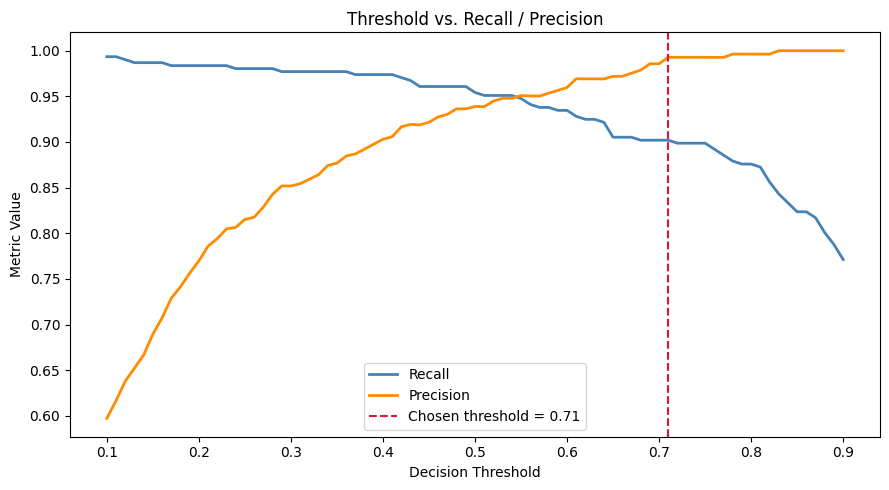


Chosen threshold  : 0.71
Recall            : 0.9020
Precision         : 0.9928
F1                : 0.9452
Accuracy          : 0.9624


In [14]:
# Scan thresholds 0.10-0.90 on a held-out 20% validation split.
# Pick the highest-precision threshold that still achieves recall >= 0.90.

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_aug, y_train_aug,
    test_size=0.2,
    stratify=y_train_aug,
    random_state=RANDOM_STATE,
)

print(f'Validation split shape : {X_val.shape}')
print('Class distribution (val):')
print(y_val.value_counts().rename({0: 'Graduate (0)', 1: 'Dropout (1)'}).to_string())

y_proba_val = best_estimator.predict_proba(X_val)

thresholds = np.arange(0.1, 0.91, 0.01)
threshold_results = {}

for t in thresholds:
    t = round(t, 2)
    y_pred_t = (y_proba_val[:, 1] >= t).astype(int)
    r = recall_score(y_val, y_pred_t, pos_label=1)
    p = precision_score(y_val, y_pred_t, pos_label=1, zero_division=0)
    a = accuracy_score(y_val, y_pred_t)
    threshold_results[t] = {'recall': r, 'precision': p, 'accuracy': a}

print(f'\nThreshold scan complete: {len(threshold_results)} thresholds evaluated.')

qualifying_t = {t: v for t, v in threshold_results.items() if v['recall'] >= 0.90}

if qualifying_t:
    optimal_threshold = max(qualifying_t, key=lambda t: qualifying_t[t]['precision'])
else:
    optimal_threshold = max(threshold_results, key=lambda t: threshold_results[t]['recall'])
    import warnings as _w
    _w.warn(f'No threshold achieves recall >= 0.90. Best: {threshold_results[optimal_threshold]["recall"]:.4f}')

threshold_recall    = threshold_results[optimal_threshold]['recall']
threshold_precision = threshold_results[optimal_threshold]['precision']
threshold_accuracy  = threshold_results[optimal_threshold]['accuracy']
threshold_f1 = (
    2 * threshold_precision * threshold_recall
    / (threshold_precision + threshold_recall + 1e-9)
)

print(f'\nOptimal threshold : {optimal_threshold:.2f}')
print(f'Recall            : {threshold_recall:.4f}')
print(f'Precision         : {threshold_precision:.4f}')
print(f'F1                : {threshold_f1:.4f}')
print(f'Accuracy          : {threshold_accuracy:.4f}')

# Plot threshold vs. recall / precision
t_vals     = sorted(threshold_results.keys())
recalls    = [threshold_results[t]['recall']    for t in t_vals]
precisions = [threshold_results[t]['precision'] for t in t_vals]

plt.figure(figsize=(9, 5))
plt.plot(t_vals, recalls,    label='Recall',    color='steelblue',  linewidth=2)
plt.plot(t_vals, precisions, label='Precision', color='darkorange', linewidth=2)
plt.axvline(x=optimal_threshold, color='crimson', linestyle='--', linewidth=1.5,
            label=f'Chosen threshold = {optimal_threshold:.2f}')
plt.title('Threshold vs. Recall / Precision')
plt.xlabel('Decision Threshold')
plt.ylabel('Metric Value')
plt.legend()
plt.tight_layout()
plt.show()

print(f'\nChosen threshold  : {optimal_threshold:.2f}')
print(f'Recall            : {threshold_recall:.4f}')
print(f'Precision         : {threshold_precision:.4f}')
print(f'F1                : {threshold_f1:.4f}')
print(f'Accuracy          : {threshold_accuracy:.4f}')

## Export Model

In [7]:
print('Retraining best model on full augmented dataset...')
final_model = clone(best_estimator)
final_model.fit(X_train_aug, y_train_aug)
print(f'Final model trained: {best_model_name}')

os.makedirs('../models', exist_ok=True)
joblib.dump(final_model, '../models/best_model.pkl')
print('Saved: ../models/best_model.pkl')

# Also save under the legacy XGBoost name for dashboard compatibility
joblib.dump(final_model, '../models/xgboost_dropout_model.pkl')
print('Saved: ../models/xgboost_dropout_model.pkl')

metadata = {
    'threshold':            optimal_threshold,
    'model_name':           best_model_name,
    'dropout_recall_cv':    hpo_results[best_model_name]['mean_recall_cv'],
    'dropout_precision_cv': hpo_results[best_model_name]['mean_precision_cv'],
    'feature_names':        X_train_aug.columns.tolist(),
}
joblib.dump(metadata, '../models/model_metadata.pkl')
print('Saved: ../models/model_metadata.pkl')
print(f'  threshold            : {metadata["threshold"]}')
print(f'  model_name           : {metadata["model_name"]}')
print(f'  dropout_recall_cv    : {metadata["dropout_recall_cv"]:.4f}')
print(f'  dropout_precision_cv : {metadata["dropout_precision_cv"]:.4f}')
print(f'  feature_names        : {len(metadata["feature_names"])} features')

# Serialization round-trip check
loaded_best = joblib.load('../models/best_model.pkl')
sample = X_train_aug.iloc[:5]
pred_mem  = final_model.predict(sample)
pred_disk = loaded_best.predict(sample)
if not np.array_equal(pred_mem, pred_disk):
    raise AssertionError('predict mismatch after serialization!')
print('Serialization round-trip verified.')

# Final summary table
summary_rows = []
for name, res in hpo_results.items():
    chosen_threshold = optimal_threshold if name == best_model_name else '-'
    expected_recall  = f'{threshold_recall:.4f}' if name == best_model_name else '-'
    summary_rows.append({
        'Model':                   name,
        'CV F1-macro':             f"{res['mean_f1_macro_cv']:.4f} ± {res['std_f1_macro_cv']:.4f}",
        'CV Dropout Recall':       f"{res['mean_recall_cv']:.4f} ± {res['std_recall_cv']:.4f}",
        'Chosen Threshold':        chosen_threshold,
        'Expected Dropout Recall': expected_recall,
    })
summary_df = pd.DataFrame(summary_rows).set_index('Model')
print('\n── Final Summary ─────────────────────────────────────────────────────')
print(summary_df.to_string())

Retraining best model on full augmented dataset...
Final model trained: XGBoost
Saved: ../models/best_model.pkl
Saved: ../models/xgboost_dropout_model.pkl
Saved: ../models/model_metadata.pkl
  threshold            : 0.71
  model_name           : XGBoost
  dropout_recall_cv    : 0.8498
  dropout_precision_cv : 0.8395
  feature_names        : 39 features
Serialization round-trip verified.

── Final Summary ─────────────────────────────────────────────────────
                         CV F1-macro CV Dropout Recall Chosen Threshold Expected Dropout Recall
Model                                                                                          
Logistic Regression  0.8759 ± 0.0056   0.8432 ± 0.0217                -                       -
Random Forest        0.8823 ± 0.0073   0.8204 ± 0.0154                -                       -
XGBoost              0.8782 ± 0.0109   0.8498 ± 0.0202             0.71                  0.9020
LightGBM             0.8763 ± 0.0099   0.8498 ± 0.0227    

## Risk Tiering

In [8]:
# Assigns enrolled students to risk tiers based on model dropout probability.
# Tiers: Low (0-25%), Moderate (25-50%), High (50-75%), Critical (75-100%).

# predict_proba returns [P(Graduate), P(Dropout)]; index 1 = dropout probability
dropout_proba = final_model.predict_proba(X_enrolled)[:, 1]

print(f'Probability range : {dropout_proba.min():.4f}  →  {dropout_proba.max():.4f}')
print(f'Mean probability  : {dropout_proba.mean():.4f}')

risk_tiers = pd.cut(
    dropout_proba,
    bins=[-0.001, 0.25, 0.50, 0.75, 1.001],
    labels=['Low', 'Moderate', 'High', 'Critical'],
)

n_null = risk_tiers.isna().sum()
if n_null > 0:
    print(f'WARNING: {n_null} students could not be classified — check probability range.')

df_enrolled['dropout_probability'] = dropout_proba
df_enrolled['risk_tier']           = risk_tiers

tier_order   = ['Critical', 'High', 'Moderate', 'Low']
distribution = (
    df_enrolled['risk_tier']
    .value_counts()
    .reindex(tier_order)
    .fillna(0)
    .astype(int)
)

print('\nRisk Tier Distribution')
print('=' * 45)
print(f'{"Tier":<12} {"Count":>6}  {"Pct":>6}   Bar')
print('-' * 45)
for tier, count in distribution.items():
    pct = count / len(df_enrolled) * 100
    bar = '█' * int(pct / 2)
    print(f'{tier:<12} {count:>6}  ({pct:5.1f}%)  {bar}')
print('=' * 45)
print(f'{"TOTAL":<12} {len(df_enrolled):>6}')

print('\nTop 10 highest-risk enrolled students:')
print(
    df_enrolled[['dropout_probability', 'risk_tier']]
    .sort_values('dropout_probability', ascending=False)
    .head(10)
    .to_string()
)

Probability range : 0.0078  →  0.9991
Mean probability  : 0.4032

Risk Tier Distribution
Tier          Count     Pct   Bar
---------------------------------------------
Critical        199  ( 25.1%)  ████████████
High             76  (  9.6%)  ████
Moderate        128  ( 16.1%)  ████████
Low             391  ( 49.2%)  ████████████████████████
TOTAL           794

Top 10 highest-risk enrolled students:
     dropout_probability risk_tier
390             0.999127  Critical
553             0.999103  Critical
509             0.998997  Critical
14              0.998893  Critical
267             0.998836  Critical
167             0.998744  Critical
156             0.998450  Critical
487             0.998402  Critical
352             0.998229  Critical
489             0.998162  Critical


## SHAP Explainability

SHAP input shape : (794, 24)
SHAP values shape: (794, 24)
Explainer initialized successfully.

Top 10 features by mean |SHAP| value:
                                feature  mean_abs_shap
    Curricular units 2nd sem (approved)       1.229312
    Curricular units 1st sem (approved)       0.598623
                Tuition fees up to date       0.372563
               Age at enrollment_scaled       0.331283
Curricular units 2nd sem (grade)_scaled       0.307101
                                 Course       0.301342
                       Application mode       0.230184
                     Scholarship holder       0.229493
               Unemployment rate_scaled       0.190531
                    Father's occupation       0.178646

Plot saved to: ../models/shap_global_importance.png


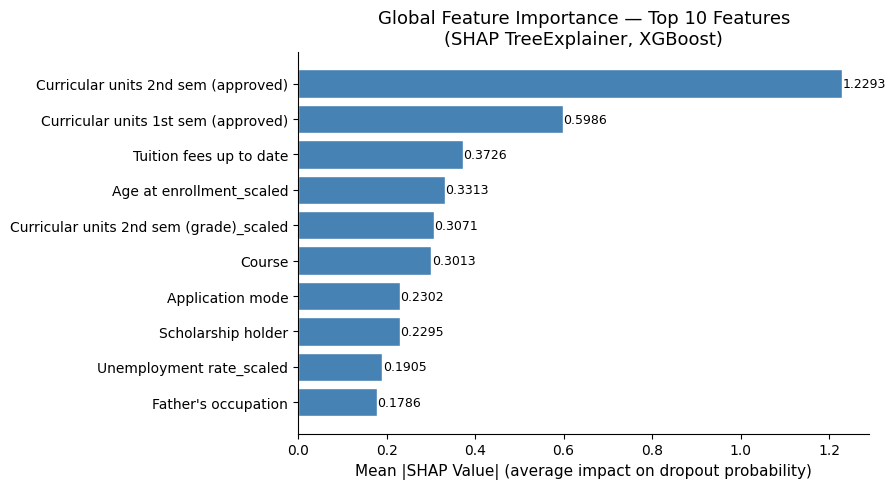


Selected student index : 390
Dropout probability    : 0.9991
Risk tier              : Critical


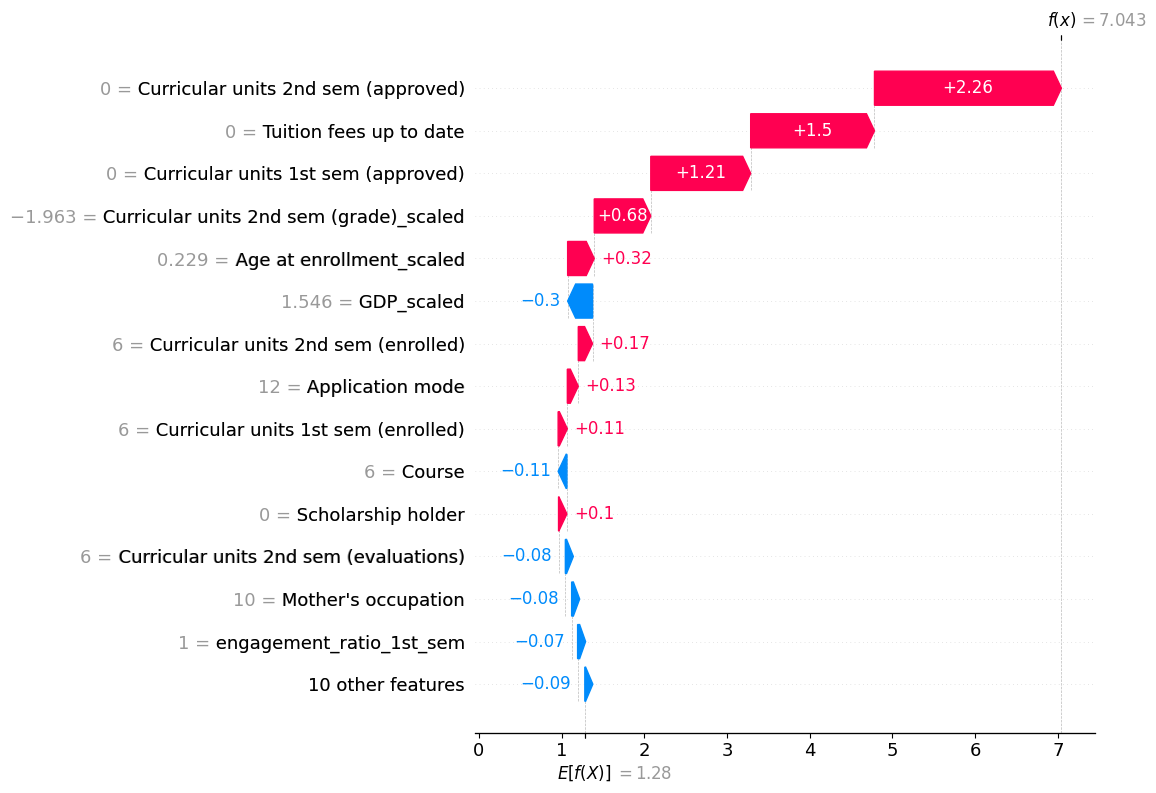

In [9]:
# Global feature importance (mean |SHAP|) + local waterfall for highest-risk student.
# Works for XGBoost and LightGBM (both are tree-based).
# For Logistic Regression / Random Forest, falls back to LinearExplainer / TreeExplainer.

# Extract the classifier from the pipeline
clf_step = final_model.named_steps['clf']

# Build the SHAP input: apply the selector transform first
selector_step = final_model.named_steps['selector']
# selector is fitted on SMOTE-augmented data; we apply it to the original enrolled features
X_shap_raw = X_enrolled[metadata['feature_names']]
X_shap = pd.DataFrame(
    selector_step.transform(X_shap_raw),
    columns=X_shap_raw.columns[selector_step.get_support()],
)

print(f'SHAP input shape : {X_shap.shape}')

# Choose explainer based on model type
if isinstance(clf_step, (XGBClassifier, LGBMClassifier, RandomForestClassifier)):
    explainer  = shap.TreeExplainer(clf_step)
    shap_values = explainer(X_shap)
    shap_vals   = shap_values.values
else:
    # LinearExplainer for Logistic Regression
    explainer  = shap.LinearExplainer(clf_step, X_shap)
    shap_vals  = explainer.shap_values(X_shap)

print(f'SHAP values shape: {shap_vals.shape}')
print('Explainer initialized successfully.')

# ── Global importance ─────────────────────────────────────────────────────────
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
feature_names_shap = X_shap.columns.tolist()

importance_df = (
    pd.DataFrame({'feature': feature_names_shap, 'mean_abs_shap': mean_abs_shap})
    .sort_values('mean_abs_shap', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print('\nTop 10 features by mean |SHAP| value:')
print(importance_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    importance_df['feature'][::-1],
    importance_df['mean_abs_shap'][::-1],
    color='steelblue', edgecolor='white',
)
ax.set_xlabel('Mean |SHAP Value| (average impact on dropout probability)', fontsize=11)
ax.set_title(
    f'Global Feature Importance — Top 10 Features\n(SHAP TreeExplainer, {best_model_name})',
    fontsize=13
)
ax.spines[['top', 'right']].set_visible(False)
for bar, val in zip(bars, importance_df['mean_abs_shap'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', ha='left', fontsize=9)
plt.tight_layout()

save_path = '../models/shap_global_importance.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'\nPlot saved to: {save_path}')
plt.show()

# ── Local waterfall for highest-risk student ──────────────────────────────────
top_idx = int(np.argmax(dropout_proba))
print(f'\nSelected student index : {top_idx}')
print(f'Dropout probability    : {dropout_proba[top_idx]:.4f}')
print(f'Risk tier              : {df_enrolled["risk_tier"].iloc[top_idx]}')

if isinstance(clf_step, (XGBClassifier, LGBMClassifier, RandomForestClassifier)):
    shap.plots.waterfall(shap_values[top_idx], max_display=15, show=True)
else:
    shap.force_plot(
        explainer.expected_value,
        shap_vals[top_idx],
        X_shap.iloc[top_idx],
        matplotlib=True,
    )